# SINDy Analysis on ABIDE Dataset
This notebook downloads a sample functional MRI timeseries from the ABIDE dataset using Nilearn, performs some preliminary data analysis, selects compatible formatting and parameters, and then subjects the data to SINDy simplicial complex analysis.

In [ ]:
# 1. Load ABIDE Dataset from Local Directory
import json
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from nilearn import datasets

from abide_sindy_terminal import _safe_filename, _sample_label, _to_jsonable, run_sindy

# Point nilearn to the current directory; it uses ./ABIDE_pcp internally
data_dir = Path.cwd()
print(f"Loading ABIDE dataset using base directory: {data_dir}")
abide = datasets.fetch_abide_pcp(data_dir=str(data_dir), derivatives="rois_cc200")
print("Local dataset load complete.")

# Extract all ROI time series
all_timeseries = abide.rois_cc200
ts_data = all_timeseries[0]
print(f"Subjects available: {len(all_timeseries)}")
print(f"Time series shape (Timepoints, ROIs): {ts_data.shape}")
print(f"SINDy input shape after transpose [Nodes, Timepoints]: {ts_data.T.shape}")
print(f"Dimension check (2D timeseries): {'OK' if ts_data.ndim == 2 else 'NOT OK'}")

Loading ABIDE dataset using base directory: /hdfs1/Data/Shubhajit/Project/New_TETON
[fetch_abide_pcp] Dataset found in /hdfs1/Data/Shubhajit/Project/New_TETON/ABIDE_pcp
Local dataset load complete.
Subjects available: 871
Time series shape (Timepoints, ROIs): (196, 200)
SINDy input shape after transpose [Nodes, Timepoints]: (200, 196)
Dimension check (2D timeseries): OK


In [2]:
abide.phenotypic

,i,Unnamed: 0,SUB_ID,X,subject,SITE_ID,FILE_ID,DX_GROUP,DSM_IV_TR,AGE_AT_SCAN,...,qc_notes_rater_1,qc_anat_rater_2,qc_anat_notes_rater_2,qc_func_rater_2,qc_func_notes_rater_2,qc_anat_rater_3,qc_anat_notes_rater_3,qc_func_rater_3,qc_func_notes_rater_3,SUB_IN_SMP
1,1,2,50003,2,50003,PITT,Pitt_0050003,1,1,24.45,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
2,2,3,50004,3,50004,PITT,Pitt_0050004,1,1,19.09,...,NaN,OK,NaN,OK,NaN,OK,NaN,OK,NaN,1
3,3,4,50005,4,50005,PITT,Pitt_0050005,1,1,13.73,...,NaN,OK,NaN,maybe,ic-parietal-cerebellum,OK,NaN,OK,NaN,0
4,4,5,50006,5,50006,PITT,Pitt_0050006,1,1,13.37,...,NaN,OK,NaN,maybe,ic-parietal slight,OK,NaN,OK,NaN,1
5,5,6,50007,6,50007,PITT,Pitt_0050007,1,1,17.78,...,NaN,OK,NaN,maybe,ic-cerebellum_temporal_lob,OK,NaN,OK,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1107,1107,1108,51583,1108,51583,SBL,SBL_0051583,1,2,35.00,...,NaN,OK,NaN,OK,ic-cerebellum-temporal_lobe,OK,NaN,OK,NaN,0
1108,1108,1109,51584,1109,51584,SBL,SBL_0051584,1,2,49.00,...,NaN,OK,NaN,maybe,vmpfc dropout,OK,NaN,OK,NaN,0
1109,1109,1110,51585,1110,51585,SBL,SBL_0051585,1,1,27.00,...,NaN,OK,NaN,maybe,ic-cerebellum-temporal_lobe,OK,NaN,OK,NaN,0
1110,1110,1111,51606,1111,51606,MAX_MUN,MaxMun_a_0051606,1,2,29.00,...,NaN,OK,NaN,maybe,ic-cerebellum,OK,NaN,OK,NaN,0


In [ ]:
# Check if each subject's time series has the same ROI count and record varying time lengths
shape_counts = {}
for idx, subject_ts in enumerate(all_timeseries):
    timepoints, rois = subject_ts.shape
    shape_counts.setdefault((timepoints, rois), 0)
    shape_counts[(timepoints, rois)] += 1

print("shape counts:")
for (timepoints, rois), count in sorted(shape_counts.items()):
    print(f"  {count} sample(s): timepoints={timepoints}, rois={rois}")

shape counts: {196: 129, 206: 28, 78: 25, 176: 211, 146: 59, 296: 120, 236: 86, 232: 1, 316: 3, 202: 1, 246: 56, 152: 29, 124: 4, 116: 119}


In [12]:
roi_count = ts_data.shape[1]

atlas_specs = [
    "cort-maxprob-thr0-1mm",
    "cort-maxprob-thr0-2mm",
    "cort-maxprob-thr25-1mm",
    "cort-maxprob-thr25-2mm",
    "cort-maxprob-thr50-1mm",
    "cort-maxprob-thr50-2mm",
    "cort-prob-1mm",
    "cort-prob-2mm",
    "cortl-maxprob-thr0-1mm",
    "cortl-maxprob-thr0-2mm",
    "cortl-maxprob-thr25-1mm",
    "cortl-maxprob-thr25-2mm",
    "cortl-maxprob-thr50-1mm",
    "cortl-maxprob-thr50-2mm",
    "cortl-prob-1mm",
    "cortl-prob-2mm",
    "sub-maxprob-thr0-1mm",
    "sub-maxprob-thr0-2mm",
    "sub-maxprob-thr25-1mm",
    "sub-maxprob-thr25-2mm",
    "sub-maxprob-thr50-1mm",
    "sub-maxprob-thr50-2mm",
    "sub-prob-1mm",
    "sub-prob-2mm",
]

rows = []
for atlas_name in atlas_specs:
    # Probabilistic atlases do not support symmetric_split in nilearn.
    symmetric_split = False if "-prob-" in atlas_name else True
    try:
        atlas = datasets.fetch_atlas_harvard_oxford(
            atlas_name,
            symmetric_split=symmetric_split,
        )
        labels = [label for label in atlas.labels if label != "Background"]
        n_labels = len(labels)
        rows.append(
            {
                "atlas": atlas_name,
                "symmetric_split": symmetric_split,
                "n_labels": n_labels,
                "diff_vs_rois_ho": abs(n_labels - roi_count),
            }
        )
    except ValueError as exc:
        print(f"Skipping {atlas_name} (symmetric_split={symmetric_split}): {exc}")

atlas_df = pd.DataFrame(rows).sort_values(["diff_vs_rois_ho", "n_labels"]).reset_index(drop=True)
print(f"rois_ho ROI count: {roi_count}")
print("Harvard-Oxford atlas label counts compared with rois_ho:")
print(atlas_df.to_string(index=False))

best_match = atlas_df.iloc[0]
print("\nClosest match:")
print(
    f"  atlas={best_match['atlas']}, symmetric_split={best_match['symmetric_split']}, "
    f"labels={best_match['n_labels']}, diff={best_match['diff_vs_rois_ho']}"
)

[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl


/tmp/ipykernel_490786/1112366557.py:35: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index                                              name
    19  Left Superior Temporal Gyrus, posterior division
    20 Right Superior Temporal Gyrus, posterior division
    93                        Left Supracalcarine Cortex

  atlas = datasets.fetch_atlas_harvard_oxford(
/tmp/ipykernel_490786/1112366557.py:35: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index                        name
    93  Left Supracalcarine Cortex
    94 Right Supracalcarine Cortex

  atlas = datasets.fetch_atlas_harvard_oxford(


[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl


/tmp/ipykernel_490786/1112366557.py:35: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index                                              name
    19  Left Superior Temporal Gyrus, posterior division
    20 Right Superior Temporal Gyrus, posterior division
    93                        Left Supracalcarine Cortex

  atlas = datasets.fetch_atlas_harvard_oxford(
/tmp/ipykernel_490786/1112366557.py:35: UserWarning: 
The following regions are present in the atlas look-up table,
but missing from the atlas image:

 index                        name
    93  Left Supracalcarine Cortex
    94 Right Supracalcarine Cortex

  atlas = datasets.fetch_atlas_harvard_oxford(


[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/royshubhajit/nilearn_data/fsl
rois_ho ROI count: 111
Harvard-Oxford atlas label counts compared with rois_ho:
                  

# 2. Data Analysis
Here, we analyze the basic characteristics of the time series and visualize a subset of the nodes over time.

--- Data Statistics ---
Mean: -0.0000
Std Dev: 44.7423
Min: -353.5698, Max: 299.3049


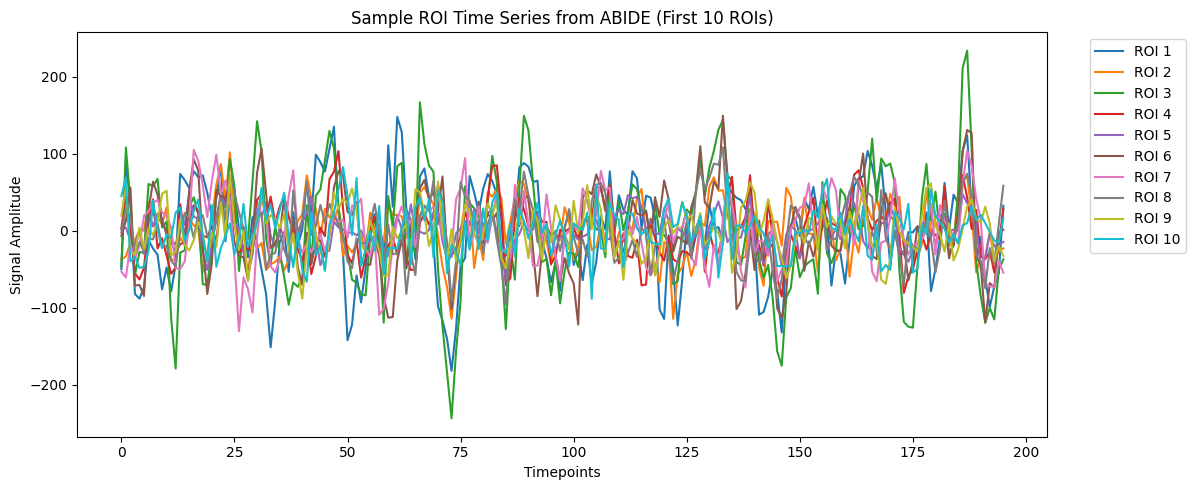

In [2]:
# Basic statistics
print("--- Data Statistics ---")
print(f"Mean: {np.mean(ts_data):.4f}")
print(f"Std Dev: {np.std(ts_data):.4f}")
print(f"Min: {np.min(ts_data):.4f}, Max: {np.max(ts_data):.4f}")

# Plot the first 10 ROIs to observe functional fluctuations
plt.figure(figsize=(12, 5))
for i in range(min(10, ts_data.shape[1])):
    plt.plot(ts_data[:, i], label=f'ROI {i+1}')
plt.title("Sample ROI Time Series from ABIDE (First 10 ROIs)")
plt.xlabel("Timepoints")
plt.ylabel("Signal Amplitude")
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

# 3. Parameter Selection for SINDy
SINDy expects `data_raw` to be in the shape `[nodes, timepoints]`. We will transpose the timeseries, select a small subset of ROIs to keep computation tractable for demonstration, and deduce the window lengths.

In [ ]:
# Transpose to [nodes, timepoints]
data_raw = ts_data.T

# For demonstration and performance, let's select the first 20 ROIs
# data_raw = data_raw[:20, :]
print(f"Data shape for SINDy [Nodes, Timepoints]: {data_raw.shape}")

# Fixed window settings
win_len = 168
window_overlap = 0.5
max_rois = min(20, data_raw.shape[0])

from sindy import SindyArgs

args = SindyArgs(
    win_len=win_len,
    stride=None,
    overlap=window_overlap,
    d_max=2,
    simpl_rho=1.0,
    scale=1.0,
    tau2_q=0.8,  # fallback quantile threshold for edge selection
    tau3_q=0.50, # fallback quantile threshold for triangle selection
)

stride = max(1, int(round(win_len * (1.0 - window_overlap))))
print(f"Data will be split into overlapping windows of length {win_len} and stride {stride}.")

Data shape for SINDy [Nodes, Timepoints]: (200, 196)
Data will be split into 1 windows of length 168.


# 4. Run SINDy
Apply the SINDy algorithm over the contiguous windows and extract the graphical and simplicial structure over time.

In [ ]:
from time import time

print("Starting processing over all samples...")
start_time = time()

processed_dir = data_dir / "abide_sindy_processed"
processed_dir.mkdir(parents=True, exist_ok=True)

sample_payloads = []
for sample_index, subject_ts in enumerate(all_timeseries):
    sample_label = _sample_label(abide, sample_index)
    print("\n" + "=" * 80)
    print(f"[sample] {sample_index + 1}/{len(all_timeseries)}: {sample_label}")
    print(f"Time series shape (Timepoints, ROIs): {subject_ts.shape}")

    try:
        sample_result = run_sindy(
            subject_ts,
            window_len=win_len,
            overlap=window_overlap,
            max_rois=max_rois,
        )
    except ValueError as exc:
        print(f"[skip] {sample_label}: {exc}")
        continue

    sample_payload = {
        "sample_index": sample_index,
        "sample_id": sample_label,
        "timepoints": int(subject_ts.shape[0]),
        "rois": int(subject_ts.shape[1]),
        **sample_result,
    }
    sample_payloads.append(sample_payload)

    sample_path = processed_dir / f"{sample_index:04d}_{_safe_filename(sample_label)}.json"
    with sample_path.open("w", encoding="utf-8") as fp:
        json.dump(_to_jsonable(sample_payload), fp, indent=2)
    print(f"[output] Saved sample result to: {sample_path}")

manifest = {
    "download_dir": str(data_dir),
    "derivatives": "rois_cc200",
    "window_len": win_len,
    "window_overlap": window_overlap,
    "max_rois": max_rois,
    "num_samples_processed": len(sample_payloads),
    "samples": [
        {
            "sample_index": payload["sample_index"],
            "sample_id": payload["sample_id"],
            "num_windows": payload["num_windows"],
            "window_len": payload["window_len"],
            "stride": payload["stride"],
        }
        for payload in sample_payloads
    ],
}

manifest_path = processed_dir / "manifest.json"
with manifest_path.open("w", encoding="utf-8") as fp:
    json.dump(_to_jsonable(manifest), fp, indent=2)
print(f"[output] Saved manifest to: {manifest_path}")

archive_path = data_dir / "abide_sindy_processed.tar.gz"
with tarfile.open(archive_path, "w:gz") as tar:
    tar.add(processed_dir, arcname="abide_sindy_processed")
print(f"[output] Saved tar archive to: {archive_path}")

end_time = time()
print(f"Processed {len(sample_payloads)} samples.")
print(f"Total processing time: {end_time - start_time:.2f} seconds.")
print("[done] Notebook pipeline completed.")

Starting processing over windows...
